# Experimento 5: Valoración Económica del Forecasting Solar

**Objetivo:** Cuantificar el coste de desvíos que genera cada modelo en el mercado eléctrico español, usando precios reales de e-sios (SPOT, desvíos a subir, desvíos a bajar).  
**Marco regulatorio:** P.O. 14.4 — Liquidación de desvíos del sistema eléctrico peninsular.

**Dependencias previas (deben haberse ejecutado en Colab antes de este notebook):**
- `01_baseline_prophet.ipynb` → `results/metrics/prophet_predictions.csv`
- `02_lightgbm_forecasting.ipynb` → `results/metrics/lgbm_predictions.csv`
- `03_baseline-lstm.ipynb` → `results/metrics/lstm_predictions.csv`
- `04_nbeats_forecasting.ipynb` → `results/metrics/nbeats_predictions.csv`
- `05_baseline_tft.ipynb` → `results/metrics/tft_predictions.csv`

Opcionales (Exp 2 y Exp 3):
- `ex2_transfer/01_nbeats_transfer.ipynb`, `02_tft_transfer.ipynb`, `03_lstm_transfer.ipynb`
- `ex3_probabilistic/01_lstm_quantile.ipynb`, `02_tft_quantile.ipynb`

In [1]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Mounted at /content/drive
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


In [2]:
# ---------------------------------------------------------------------------
# CELDA 1 — Setup Colab / Local
# ---------------------------------------------------------------------------
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO = '/content/drive/MyDrive/_UOC/tfm-solar-forecasting/'
    os.chdir(REPO)
    print(f'Working dir: {os.getcwd()}')

# Añadir src al path si no está ya
if 'src' not in sys.path[0]:
    sys.path.insert(0, os.path.abspath('.'))
    sys.path.insert(0, os.path.abspath('src'))

# Importaciones estándar
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

print('Setup completado.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/_UOC/tfm-solar-forecasting
Setup completado.


In [3]:
# ---------------------------------------------------------------------------
# CELDA 2 — Rutas y plantas
# ---------------------------------------------------------------------------
ROOT = Path('.')
ESIOS_DIR   = ROOT / 'data' / 'esios'
METRICS_DIR = ROOT / 'results' / 'metrics'
EX2_DIR     = ROOT / 'results' / 'ex2_transfer'
EX3_DIR     = ROOT / 'results' / 'ex3_probabilistic'
OUT_DIR     = ROOT / 'results' / 'ex1_compare'
FIG_DIR     = ROOT / 'results' / 'figures'

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Plantas activas (6 plantas dataset)
PLANTAS = ['UPGARNACHA', 'PIZARRO', 'NBALBOA', 'RODRI', 'UFMULA', 'TALASOL']

# Test period
TEST_START = '2025-11-01'
TEST_END   = '2025-12-31'

# Factor de anualización (61 días de test)
N_TEST_DAYS   = 61
ANNUAL_FACTOR = 365.0 / N_TEST_DAYS

print(f'Rutas configuradas.')
print(f'Plantas activas: {PLANTAS}')
print(f'Factor anualización: {ANNUAL_FACTOR:.2f}x')

Rutas configuradas.
Plantas activas: ['UPGARNACHA', 'PIZARRO', 'NBALBOA', 'RODRI', 'UFMULA', 'TALASOL']
Factor anualización: 5.98x


---
## Bloque 1: Carga y alineación de precios ESIOS

In [4]:
# ---------------------------------------------------------------------------
# CELDA 3 — Carga precios ESIOS y alineación horaria
# ---------------------------------------------------------------------------

def load_esios_csv(filepath, value_col='value'):
    """Carga CSV de e-sios con separador ';' y parsea datetime."""
    df = pd.read_csv(filepath, sep=';')
    # Truncar offset TZ (+01:00/+02:00) antes de parsear: pandas 2.x devuelve
    # object dtype con utc=False si los strings tienen timezone info
    df['datetime'] = pd.to_datetime(df['datetime'].str[:19], format='%Y-%m-%dT%H:%M:%S')
    # Truncar a hora (ignorar minutos, que solo aplica al SPOT)
    df['hora'] = df['datetime'].dt.floor('h')
    # Para SPOT (datos cuartohorarios): tomar primer valor de cada hora
    df = df.drop_duplicates(subset='hora', keep='first')
    df = df.set_index('hora')[['value']].rename(columns={'value': value_col})
    return df

# Cargar los 3 datasets de precios
df_spot   = load_esios_csv(ESIOS_DIR / 'PrecioMercadoSPOTDiario_2025.csv',      'spot_eur_mwh')
df_subir  = load_esios_csv(ESIOS_DIR / 'PrecioDeCobroDesviosASubir_2025.csv',   'cobro_subir_eur_mwh')
df_bajar  = load_esios_csv(ESIOS_DIR / 'PrecioDePagoDesviosABajar_2025.csv',    'pago_bajar_eur_mwh')

# Combinar en un DataFrame único
prices = df_spot.join(df_subir, how='inner').join(df_bajar, how='inner')
prices = prices.sort_index()

print(f'Precios ESIOS cargados: {len(prices)} horas ({prices.index[0]} → {prices.index[-1]})')
print(f'Huecos detectados: {prices.isnull().sum().to_dict()}')
print()

# Estadísticas descriptivas
print(prices.describe().round(2))

Precios ESIOS cargados: 8759 horas (2025-01-01 00:00:00 → 2025-12-31 23:00:00)
Huecos detectados: {'spot_eur_mwh': 0, 'cobro_subir_eur_mwh': 0, 'pago_bajar_eur_mwh': 0}

       spot_eur_mwh  cobro_subir_eur_mwh  pago_bajar_eur_mwh
count       8759.00              8759.00             8759.00
mean          65.37                42.87               72.76
std           47.80                42.02               45.38
min          -15.00              -493.28             -213.26
25%           19.74                 3.80               38.37
50%           70.00                44.37               82.47
75%          104.38                75.32              104.73
max          240.00               258.19              420.99


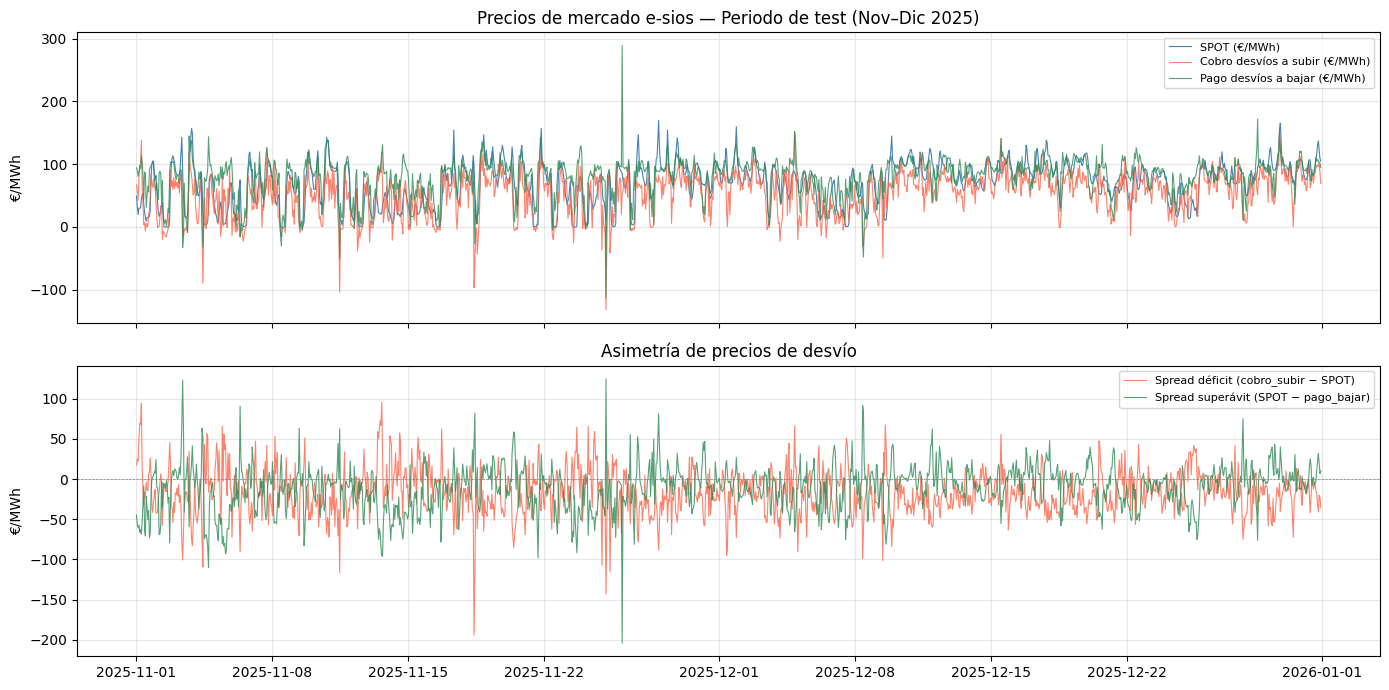

Horas con cobro_subir < SPOT (periodo test): 1145 de 1464 (78.2%)
Spread medio déficit: -16.61 €/MWh
Spread medio superávit: -11.26 €/MWh


In [5]:
# ---------------------------------------------------------------------------
# CELDA 4 — Visualización de precios y verificación de sanidad
# ---------------------------------------------------------------------------

# Filtrar al periodo de test para los gráficos
prices_test = prices.loc[TEST_START:TEST_END]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(prices_test.index, prices_test['spot_eur_mwh'],
             label='SPOT (€/MWh)', color='steelblue', linewidth=0.8)
axes[0].plot(prices_test.index, prices_test['cobro_subir_eur_mwh'],
             label='Cobro desvíos a subir (€/MWh)', color='tomato', linewidth=0.8, alpha=0.8)
axes[0].plot(prices_test.index, prices_test['pago_bajar_eur_mwh'],
             label='Pago desvíos a bajar (€/MWh)', color='seagreen', linewidth=0.8, alpha=0.8)
axes[0].set_ylabel('€/MWh')
axes[0].set_title('Precios de mercado e-sios — Periodo de test (Nov–Dic 2025)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Spread: cobro_subir - spot (positivo = mayor coste para déficit)
spread_deficit   = prices_test['cobro_subir_eur_mwh'] - prices_test['spot_eur_mwh']
spread_superavit = prices_test['spot_eur_mwh'] - prices_test['pago_bajar_eur_mwh']
axes[1].plot(prices_test.index, spread_deficit,
             label='Spread déficit (cobro_subir − SPOT)', color='tomato', linewidth=0.8, alpha=0.8)
axes[1].plot(prices_test.index, spread_superavit,
             label='Spread superávit (SPOT − pago_bajar)', color='seagreen', linewidth=0.8, alpha=0.8)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[1].set_ylabel('€/MWh')
axes[1].set_title('Asimetría de precios de desvío')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'economic_prices_esios.png', dpi=150, bbox_inches='tight')
plt.show()

# Verificar: ¿cuántas horas tiene cobro_subir < SPOT (spread negativo)?
n_neg_deficit = (spread_deficit < 0).sum()
print(f'Horas con cobro_subir < SPOT (periodo test): {n_neg_deficit} de {len(prices_test)} ({n_neg_deficit/len(prices_test)*100:.1f}%)')
print(f'Spread medio déficit: {spread_deficit.mean():.2f} €/MWh')
print(f'Spread medio superávit: {spread_superavit.mean():.2f} €/MWh')

---
## Bloque 2: Función de coste de desvíos (P.O. 14.4)

In [6]:
# ---------------------------------------------------------------------------
# CELDA 5 — Función de coste de desvíos según P.O. 14.4
# ---------------------------------------------------------------------------

def calculate_imbalance_cost(y_real, y_pred, prices_df):
    """
    Calcula el coste de desvíos por hora según P.O. 14.4.

    Unidades de entrada:
        y_real / y_pred : quantity_sum en unidades ESIOS = suma de 4 lecturas
                          cuartohorarias de potencia media en MW.
        Conversión a energía horaria: quantity_sum × 0.25 h = MWh

    Fórmula (coste siempre >= 0):
        deficit_h     = max(0, programado_h - real_h)              [MWh]
        superavit_h   = max(0, real_h - programado_h)              [MWh]
        coste_def_h   = deficit_h   × cobro_subir_h                [€]
        coste_sup_h   = superavit_h × (spot_h - pago_bajar_h)      [€]
        coste_total_h = coste_def_h + coste_sup_h                  [€]

    Args:
        y_real:     Series con producción real (quantity_sum, unidades ESIOS MW×4),
                    indexada por datetime horario.
        y_pred:     Series con predicción, mismo índice y unidades.
        prices_df:  DataFrame indexado por datetime (hourly) con columnas:
                    ['spot_eur_mwh', 'cobro_subir_eur_mwh', 'pago_bajar_eur_mwh']

    Returns:
        DataFrame horario con columnas:
            real_mwh, pred_mwh, ingresos_spot_eur,
            deficit_mwh, superavit_mwh,
            desvio_subir_eur, desvio_bajar_eur, coste_total_eur
    """
    # Alinear índices
    idx  = y_real.index.intersection(y_pred.index).intersection(prices_df.index)
    real = y_real.loc[idx]
    pred = y_pred.loc[idx]
    p    = prices_df.loc[idx]

    # Conversión a MWh: suma de 4 lecturas MW × 0.25 h/lectura
    real_mwh = real * 0.25
    pred_mwh = pred * 0.25

    # Ingresos por precio SPOT (producción real valorada a precio spot)
    ingresos_spot = real_mwh * p['spot_eur_mwh']

    # Desviaciones (siempre >= 0)
    deficit   = (pred_mwh - real_mwh).clip(lower=0)
    superavit = (real_mwh - pred_mwh).clip(lower=0)

    # Costes según P.O. 14.4
    desvio_subir = deficit   * p['cobro_subir_eur_mwh']
    desvio_bajar = superavit * (p['spot_eur_mwh'] - p['pago_bajar_eur_mwh'])

    # desvio_bajar puede ser negativo si pago_bajar > SPOT (situación anómala)
    desvio_bajar = desvio_bajar.clip(lower=0)

    result = pd.DataFrame({
        'real_mwh':          real_mwh,
        'pred_mwh':          pred_mwh,
        'ingresos_spot_eur': ingresos_spot,
        'deficit_mwh':       deficit,
        'superavit_mwh':     superavit,
        'desvio_subir_eur':  desvio_subir,
        'desvio_bajar_eur':  desvio_bajar,
        'coste_total_eur':   desvio_subir + desvio_bajar,
    }, index=idx)

    return result


# --------------- TESTS DE SANIDAD ---------------
print('Test 1: predicción perfecta → coste = 0')
y = pd.Series([100.0, 200.0, 300.0],
              index=pd.date_range('2025-11-01', periods=3, freq='h'))
p_test = pd.DataFrame({
    'spot_eur_mwh':         [50.0, 60.0, 55.0],
    'cobro_subir_eur_mwh':  [60.0, 70.0, 65.0],
    'pago_bajar_eur_mwh':   [40.0, 50.0, 45.0],
}, index=y.index)
r = calculate_imbalance_cost(y, y, p_test)
assert r['coste_total_eur'].sum() == 0.0, 'Fallo: predicción perfecta debe dar coste 0'
print('  OK - coste total = 0.0 €')

print('Test 2: todo déficit (pred > real) → solo desvio_subir')
y_real = pd.Series([50.0, 50.0], index=pd.date_range('2025-11-01', periods=2, freq='h'))
y_pred = pd.Series([100.0, 100.0], index=y_real.index)
p_test2 = pd.DataFrame({
    'spot_eur_mwh':         [50.0, 50.0],
    'cobro_subir_eur_mwh':  [80.0, 80.0],
    'pago_bajar_eur_mwh':   [40.0, 40.0],
}, index=y_real.index)
r2 = calculate_imbalance_cost(y_real, y_pred, p_test2)
# deficit = (100-50) × 0.25 = 12.5 MWh/h; coste = 12.5 × 80 = 1000 €/h × 2h = 2000 €
expected = 2000.0
assert abs(r2['coste_total_eur'].sum() - expected) < 0.001, \
    f'Esperado {expected}, obtenido {r2["coste_total_eur"].sum()}'
print(f'  OK - coste total = {r2["coste_total_eur"].sum():.1f} € (esperado {expected:.0f} €)')

print('Test 3: todo superávit (real > pred) → solo desvio_bajar')
r3 = calculate_imbalance_cost(y_pred, y_real, p_test2)
# superavit = 12.5 MWh/h; coste = 12.5 × (50-40) = 125 €/h × 2h = 250 €
expected3 = 250.0
assert abs(r3['coste_total_eur'].sum() - expected3) < 0.001, \
    f'Esperado {expected3}, obtenido {r3["coste_total_eur"].sum()}'
print(f'  OK - coste total = {r3["coste_total_eur"].sum():.1f} € (esperado {expected3:.0f} €)')

print('\nTodos los tests superados.')

Test 1: predicción perfecta → coste = 0
  OK - coste total = 0.0 €
Test 2: todo déficit (pred > real) → solo desvio_subir
  OK - coste total = 2000.0 € (esperado 2000 €)
Test 3: todo superávit (real > pred) → solo desvio_bajar
  OK - coste total = 250.0 € (esperado 250 €)

Todos los tests superados.


---
## Bloque 3: Coste de desvíos por modelo × planta (Exp 1)

In [7]:
# ---------------------------------------------------------------------------
# CELDA 6 — Carga de predicciones Exp 1
# ---------------------------------------------------------------------------

MODELOS_EX1 = {
    'Prophet':  OUT_DIR / 'metrics' / 'prophet_predictions.csv',
    'LightGBM': OUT_DIR / 'metrics' / 'lightgbm_predictions.csv',
    'LSTM':     OUT_DIR / 'metrics' / 'lstm_predictions.csv',
    'N-BEATS':  OUT_DIR / 'metrics' / 'nbeats_predictions.csv',
    'TFT':      OUT_DIR / 'metrics' / 'tft_predictions.csv',
}

def load_predictions(filepath, model_name):
    """
    Carga un CSV de predicciones con columnas [timestamp, y_true, y_pred, planta_nombre, ...].
    Devuelve DataFrame filtrado a las 6 plantas y el periodo de test.
    """
    if not Path(filepath).exists():
        print(f'  AVISO: {filepath} no encontrado. Ejecutar el notebook de {model_name} primero.')
        return None

    df = pd.read_csv(filepath)

    # Normalizar columna timestamp
    ts_col = 'timestamp' if 'timestamp' in df.columns else df.columns[0]
    df['timestamp'] = pd.to_datetime(df[ts_col].str[:19])
    df['timestamp'] = df['timestamp'].dt.floor('h')

    # Filtrar plantas activas y periodo de test
    if 'planta_nombre' not in df.columns:
        print(f'  AVISO: columna planta_nombre no encontrada en {filepath}')
        return None

    df = df[df['planta_nombre'].isin(PLANTAS)]
    df = df[(df['timestamp'] >= TEST_START) & (df['timestamp'] <= TEST_END)]

    if len(df) == 0:
        print(f'  AVISO: {model_name} — sin datos para las 6 plantas en el periodo de test.')
        print(f'         Plantas disponibles: {pd.read_csv(filepath)["planta_nombre"].unique().tolist()}')
        return None

    df = df.set_index('timestamp')
    return df[['y_true', 'y_pred', 'planta_nombre']]


# Cargar todas las predicciones
preds_ex1 = {}
for modelo, filepath in MODELOS_EX1.items():
    df = load_predictions(filepath, modelo)
    if df is not None:
        preds_ex1[modelo] = df
        print(f'  {modelo}: {len(df)} filas, plantas: {sorted(df["planta_nombre"].unique())}')

print(f'\nModelos con predicciones cargadas: {list(preds_ex1.keys())}')

  Prophet: 7205 filas, plantas: ['NBALBOA', 'RODRI', 'TALASOL', 'UFMULA', 'UPGARNACHA']
  LightGBM: 7205 filas, plantas: ['NBALBOA', 'RODRI', 'TALASOL', 'UFMULA', 'UPGARNACHA']
  LSTM: 7205 filas, plantas: ['NBALBOA', 'RODRI', 'TALASOL', 'UFMULA', 'UPGARNACHA']
  N-BEATS: 7205 filas, plantas: ['NBALBOA', 'RODRI', 'TALASOL', 'UFMULA', 'UPGARNACHA']
  TFT: 6960 filas, plantas: ['NBALBOA', 'RODRI', 'TALASOL', 'UFMULA', 'UPGARNACHA']

Modelos con predicciones cargadas: ['Prophet', 'LightGBM', 'LSTM', 'N-BEATS', 'TFT']


In [8]:
# ---------------------------------------------------------------------------
# CELDA 6b — Alinear todos los modelos al primer timestamp de TFT (por planta)
# ---------------------------------------------------------------------------
# TFT pierde las primeras ~49 horas por warm-up. Para comparación justa,
# todos los modelos se filtran para que empiecen en el mismo timestamp que TFT.

if 'TFT' in preds_ex1:
    tft_preds = preds_ex1['TFT']
    # Calcular primer timestamp de TFT por planta
    tft_starts = (
        tft_preds.reset_index()
        .groupby('planta_nombre')['timestamp']
        .min()
        .to_dict()
    )
    print("Primer timestamp TFT por planta:")
    for p, ts in sorted(tft_starts.items()):
        print(f"  {p}: {ts}")

    print("\nAlineando todos los modelos:")
    for modelo in list(preds_ex1.keys()):
        df = preds_ex1[modelo].reset_index()
        n_antes = len(df)
        mask = df.apply(
            lambda row: row['timestamp'] >= tft_starts.get(row['planta_nombre'], row['timestamp']),
            axis=1
        )
        df_filtered = df[mask].set_index('timestamp')
        preds_ex1[modelo] = df_filtered
        n_despues = len(df_filtered)
        print(f"  {modelo}: {n_antes} → {n_despues} filas ({n_antes - n_despues} descartadas)")

    # Recalcular ANNUAL_FACTOR con el periodo efectivo (inicio del primer TFT)
    tft_start_global = min(tft_starts.values())
    n_days_effective = (pd.Timestamp(TEST_END) - tft_start_global).total_seconds() / 86400
    ANNUAL_FACTOR = 365 / n_days_effective
    print(f"\nANNUAL_FACTOR actualizado: 365/{n_days_effective:.1f} = {ANNUAL_FACTOR:.3f}")
else:
    print("TFT no disponible — no se aplica alineación temporal")
    print(f"ANNUAL_FACTOR mantenido: {ANNUAL_FACTOR:.3f}")

Primer timestamp TFT por planta:
  NBALBOA: 2025-11-03 01:00:00
  RODRI: 2025-11-03 01:00:00
  TALASOL: 2025-11-03 01:00:00
  UFMULA: 2025-11-03 01:00:00
  UPGARNACHA: 2025-11-03 01:00:00

Alineando todos los modelos:
  Prophet: 7205 → 6960 filas (245 descartadas)
  LightGBM: 7205 → 6960 filas (245 descartadas)
  LSTM: 7205 → 6960 filas (245 descartadas)
  N-BEATS: 7205 → 6960 filas (245 descartadas)
  TFT: 6960 → 6960 filas (0 descartadas)

ANNUAL_FACTOR actualizado: 365/58.0 = 6.298


In [9]:
# ---------------------------------------------------------------------------
# CELDA 7 — Cálculo de costes Exp 1 (planta × modelo)
# ---------------------------------------------------------------------------

if not preds_ex1:
    print('ERROR: No hay predicciones de Exp 1 disponibles.')
    print('Ejecutar primero los notebooks 01-05 en Colab con las 6 plantas activas.')
else:
    records_ex1 = []

    for modelo, df_pred in preds_ex1.items():
        for planta in sorted(df_pred['planta_nombre'].unique()):
            df_p = df_pred[df_pred['planta_nombre'] == planta]

            y_real   = df_p['y_true']
            y_pred_m = df_p['y_pred']

            cost_df = calculate_imbalance_cost(y_real, y_pred_m, prices)

            n_horas        = len(cost_df)
            total_mwh      = cost_df['real_mwh'].sum()
            ingresos_spot  = cost_df['ingresos_spot_eur'].sum()
            desvio_subir   = cost_df['desvio_subir_eur'].sum()
            desvio_bajar   = cost_df['desvio_bajar_eur'].sum()
            coste_total    = cost_df['coste_total_eur'].sum()

            mae = (y_real - y_pred_m).abs().mean()

            records_ex1.append({
                'modelo':             modelo,
                'planta':             planta,
                'n_horas':            n_horas,
                'produccion_mwh':     round(total_mwh, 1),
                'mae':                round(mae, 2),
                'ingresos_spot_eur':  round(ingresos_spot, 0),
                'desvio_subir_eur':   round(desvio_subir, 0),
                'desvio_bajar_eur':   round(desvio_bajar, 0),
                'coste_test_eur':     round(coste_total, 0),
                'coste_anual_eur':    round(coste_total * ANNUAL_FACTOR, 0),
                'coste_por_mwh':      round(coste_total / total_mwh if total_mwh > 0 else 0, 4),
                'pct_ingresos':       round(coste_total / ingresos_spot * 100 if ingresos_spot > 0 else 0, 2),
            })

    df_costs_ex1 = pd.DataFrame(records_ex1)

    df_costs_ex1.to_csv(OUT_DIR / 'economic_valuation_ex1.csv', index=False)
    print(f'Resultados guardados en {OUT_DIR}/economic_valuation_ex1.csv')
    print()
    cols_show = ['modelo', 'planta', 'mae', 'ingresos_spot_eur',
                 'desvio_subir_eur', 'desvio_bajar_eur', 'coste_test_eur',
                 'coste_anual_eur', 'pct_ingresos']
    print(df_costs_ex1[cols_show].to_string())

Resultados guardados en results/ex1_compare/economic_valuation_ex1.csv

      modelo      planta     mae  ingresos_spot_eur  desvio_subir_eur  desvio_bajar_eur  coste_test_eur  coste_anual_eur  pct_ingresos
0    Prophet     NBALBOA  101.76          2669124.0         1219037.0           10113.0       1229149.0        7740726.0         46.05
1    Prophet       RODRI   29.87          1218314.0          432065.0           20833.0        452898.0        2852183.0         37.17
2    Prophet     TALASOL   78.57          1912707.0         1376804.0            3475.0       1380278.0        8692479.0         72.16
3    Prophet      UFMULA   96.55          3946450.0          721703.0          158418.0        880122.0        5542679.0         22.30
4    Prophet  UPGARNACHA   42.14           764063.0           11838.0          122463.0        134301.0         845780.0         17.58
5   LightGBM     NBALBOA   75.23          2669124.0           67655.0          128096.0        195751.0        1232767

In [10]:
# ---------------------------------------------------------------------------
# CELDA 8 — Tabla resumen y % reducción vs. Prophet
# ---------------------------------------------------------------------------

if 'df_costs_ex1' in dir() and len(df_costs_ex1) > 0:
    # Tabla pivotada: plantas × modelos (coste anual €)
    pivot_anual = df_costs_ex1.pivot_table(
        values='coste_anual_eur', index='planta', columns='modelo'
    ).round(0)

    # % reducción vs Prophet
    if 'Prophet' in pivot_anual.columns:
        for col in pivot_anual.columns:
            if col != 'Prophet':
                pivot_anual[f'{col}_vs_Prophet_%'] = (
                    (pivot_anual['Prophet'] - pivot_anual[col]) / pivot_anual['Prophet'] * 100
                ).round(1)

    print('=== Coste anual de desvíos (€/año) por planta y modelo ===')
    print(pivot_anual.to_string())
    print()

    # Coste medio por modelo (media de todas las plantas)
    mean_cost = df_costs_ex1.groupby('modelo')['coste_anual_eur'].mean().sort_values()
    print('=== Coste anual medio por modelo (media 6 plantas) ===')
    print(mean_cost.round(0).to_string())
    print()

    # % de ingresos SPOT estimados
    # Ingreso SPOT estimado = produccion_mwh * precio_spot_medio * factor_anual
    spot_medio = prices.loc[TEST_START:TEST_END, 'spot_eur_mwh'].mean()
    print(f'Precio SPOT medio en periodo test: {spot_medio:.2f} €/MWh')
    df_costs_ex1['ingresos_spot_anual_eur'] = (
        df_costs_ex1['produccion_mwh'] * ANNUAL_FACTOR * spot_medio
    ).round(0)
    df_costs_ex1['pct_ingresos'] = (
        df_costs_ex1['coste_anual_eur'] / df_costs_ex1['ingresos_spot_anual_eur'] * 100
    ).round(2)

    pivot_pct = df_costs_ex1.pivot_table(
        values='pct_ingresos', index='planta', columns='modelo'
    ).round(2)
    print('=== Coste de desvíos como % de ingresos SPOT anuales ===')
    print(pivot_pct.to_string())

=== Coste anual de desvíos (€/año) por planta y modelo ===
modelo           LSTM   LightGBM    N-BEATS    Prophet        TFT  LSTM_vs_Prophet_%  LightGBM_vs_Prophet_%  N-BEATS_vs_Prophet_%  TFT_vs_Prophet_%
planta                                                                                                                                             
NBALBOA     1179170.0  1232767.0  3396019.0  7740726.0  1214016.0               84.8                   84.1                  56.1              84.3
RODRI        698844.0   725809.0  2648962.0  2852183.0  1008261.0               75.5                   74.6                   7.1              64.6
TALASOL     1642065.0  1497737.0  1521579.0  8692479.0   966099.0               81.1                   82.8                  82.5              88.9
UFMULA      2725432.0  2656236.0  2701741.0  5542679.0  3123657.0               50.8                   52.1                  51.3              43.6
UPGARNACHA  1058602.0   861563.0   615151.0   845780.

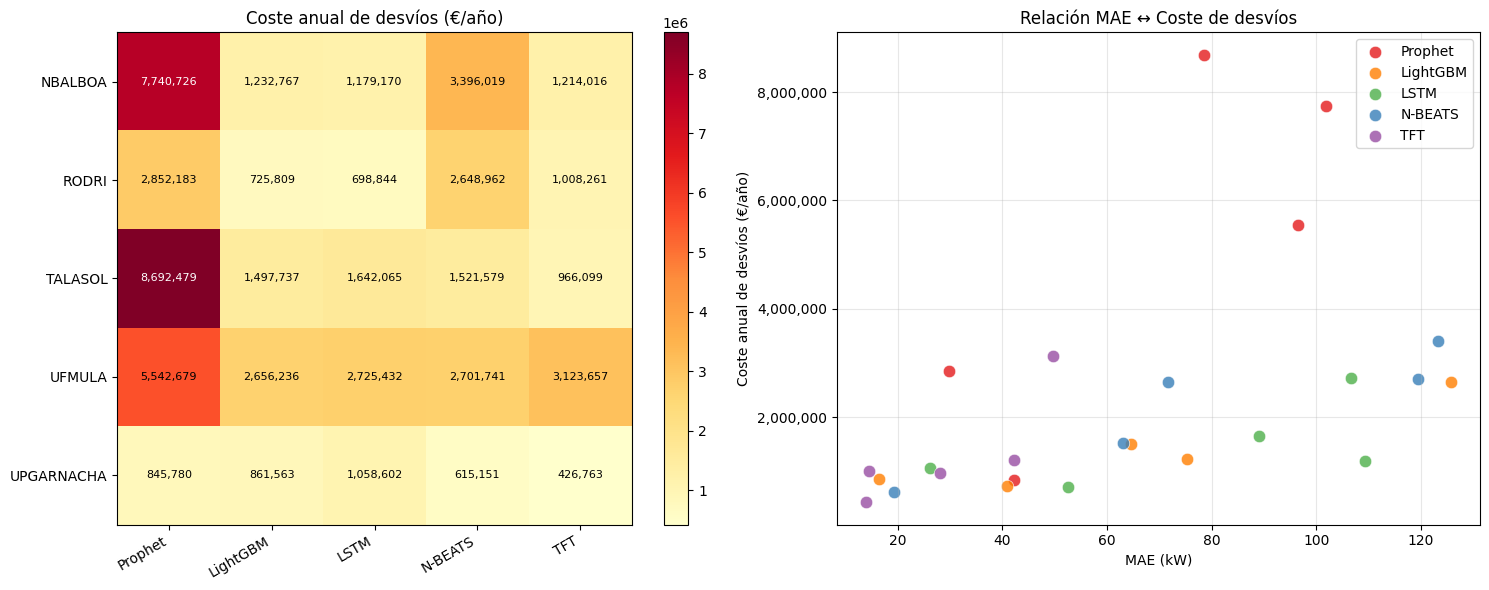

In [11]:
# ---------------------------------------------------------------------------
# CELDA 9 — Visualizaciones Exp 1
# ---------------------------------------------------------------------------

if 'df_costs_ex1' in dir() and len(df_costs_ex1) > 0:
    ORDER_MODELOS = ['Prophet', 'LightGBM', 'LSTM', 'N-BEATS', 'TFT']
    ORDER_MODELOS = [m for m in ORDER_MODELOS if m in df_costs_ex1['modelo'].unique()]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # --- Heatmap coste anual ---
    pivot_heat = df_costs_ex1.pivot_table(
        values='coste_anual_eur', index='planta', columns='modelo'
    ).reindex(columns=ORDER_MODELOS)

    im = axes[0].imshow(pivot_heat.values, cmap='YlOrRd', aspect='auto')
    axes[0].set_xticks(range(len(pivot_heat.columns)))
    axes[0].set_xticklabels(pivot_heat.columns, rotation=30, ha='right')
    axes[0].set_yticks(range(len(pivot_heat.index)))
    axes[0].set_yticklabels(pivot_heat.index)
    axes[0].set_title('Coste anual de desvíos (€/año)')
    plt.colorbar(im, ax=axes[0])

    for i in range(len(pivot_heat.index)):
        for j in range(len(pivot_heat.columns)):
            val = pivot_heat.values[i, j]
            if not np.isnan(val):
                axes[0].text(j, i, f'{val:,.0f}', ha='center', va='center',
                             fontsize=8, color='black' if val < pivot_heat.values.max() * 0.7 else 'white')

    # --- Scatter MAE vs Coste ---
    colors = {'Prophet': '#e41a1c', 'LightGBM': '#ff7f00', 'LSTM': '#4daf4a',
              'N-BEATS': '#377eb8', 'TFT': '#984ea3'}

    for modelo in ORDER_MODELOS:
        sub = df_costs_ex1[df_costs_ex1['modelo'] == modelo]
        axes[1].scatter(sub['mae'], sub['coste_anual_eur'],
                        label=modelo, color=colors.get(modelo, 'gray'),
                        s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

    axes[1].set_xlabel('MAE (kW)')
    axes[1].set_ylabel('Coste anual de desvíos (€/año)')
    axes[1].set_title('Relación MAE ↔ Coste de desvíos')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'economic_cost_heatmap_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

=== Top 15 horas con mayor coste de desvío — modelo TFT ===

      Día-Hora  Planta  Real (MWh)  Predicho (MWh)  Desvío (MWh)  Ingreso SPOT (€)  Coste subir (€)  Coste bajar (€)  Coste total (€)                  Tipo
2025-12-02 11h  UFMULA       167.9           309.8         141.9             14439            12127                0            12127   Déficit (pred>real)
2025-12-22 13h  UFMULA       137.1           281.3         144.2              8290            10812                0            10812   Déficit (pred>real)
2025-12-27 12h  UFMULA       163.2           311.5         148.3             11199            10003                0            10003   Déficit (pred>real)
2025-12-12 10h  UFMULA        57.8           174.3         116.5              6271             9651                0             9651   Déficit (pred>real)
2025-11-13 13h  UFMULA       109.4           211.3         101.9              2404             9638                0             9638   Déficit (pred>real)
202

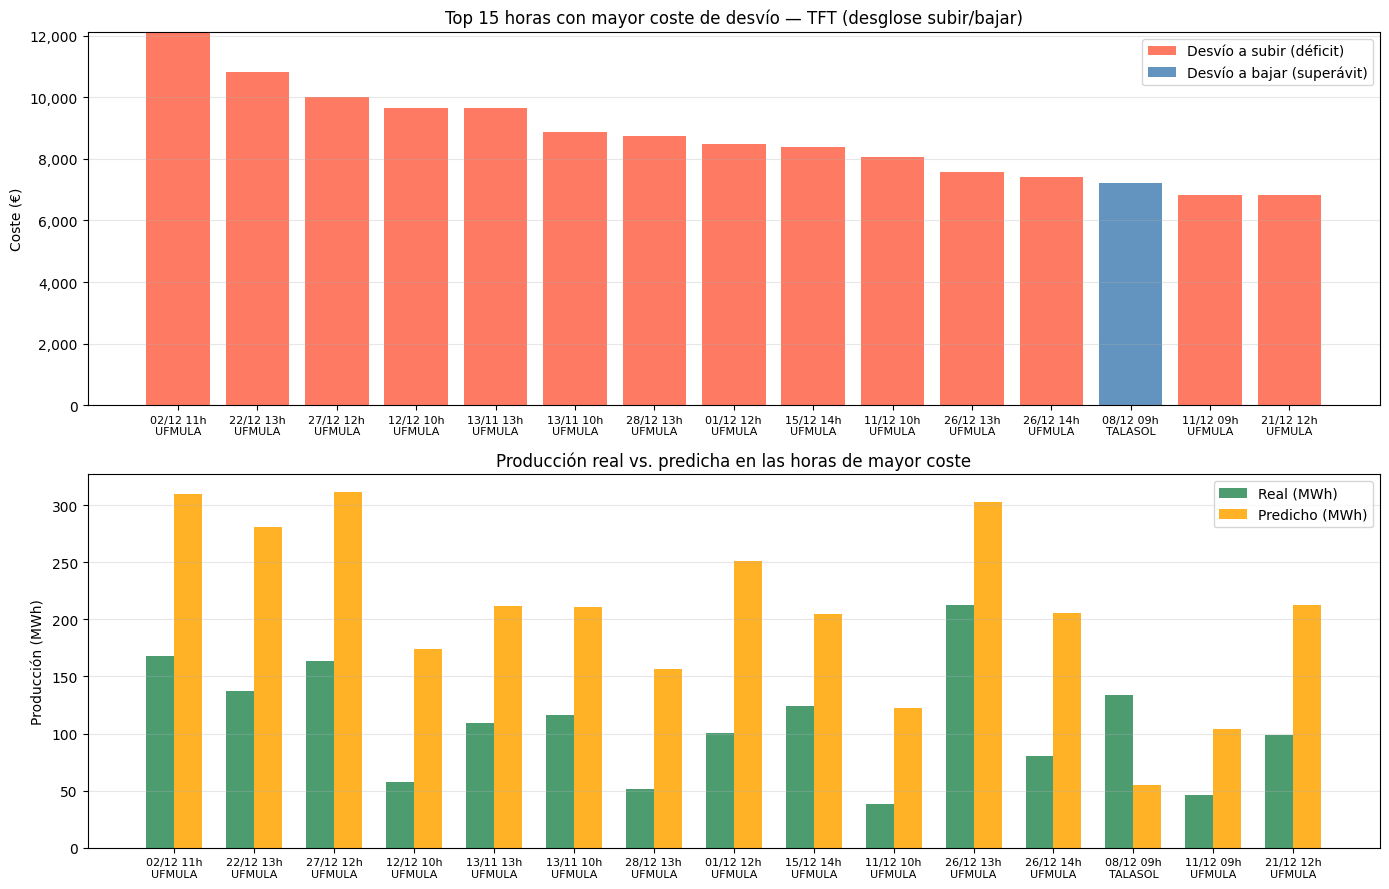


Tabla exportada → results/ex1_compare/top15_worst_hours_tft.csv


In [12]:
# ---------------------------------------------------------------------------
# CELDA 9b — Top 15 horas con mayor coste de desvíos (TFT, todas las plantas)
# ---------------------------------------------------------------------------

if 'TFT' in preds_ex1:
    # Calcular costes hora × planta para TFT
    tft_cost_rows = []
    for planta in sorted(preds_ex1['TFT']['planta_nombre'].unique()):
        df_p = preds_ex1['TFT'][preds_ex1['TFT']['planta_nombre'] == planta]
        cost_df = calculate_imbalance_cost(df_p['y_true'], df_p['y_pred'], prices)
        cost_df['planta'] = planta
        tft_cost_rows.append(cost_df)

    df_tft_all = pd.concat(tft_cost_rows).sort_values('coste_total_eur', ascending=False)

    top15 = df_tft_all.head(15).copy()
    top15.index.name = 'datetime'
    top15 = top15.reset_index()

    # Tipo de desvío dominante en cada hora
    top15['tipo_desvio'] = np.where(
        top15['desvio_subir_eur'] >= top15['desvio_bajar_eur'], 'Déficit (pred>real)', 'Superávit (real>pred)'
    )

    top15_display = pd.DataFrame({
        'Día-Hora':           top15['datetime'].dt.strftime('%Y-%m-%d %Hh'),
        'Planta':             top15['planta'],
        'Real (MWh)':         top15['real_mwh'].round(1),
        'Predicho (MWh)':     top15['pred_mwh'].round(1),
        'Desvío (MWh)':       (top15['pred_mwh'] - top15['real_mwh']).round(1),
        'Ingreso SPOT (€)':   top15['ingresos_spot_eur'].round(0).astype(int),
        'Coste subir (€)':    top15['desvio_subir_eur'].round(0).astype(int),
        'Coste bajar (€)':    top15['desvio_bajar_eur'].round(0).astype(int),
        'Coste total (€)':    top15['coste_total_eur'].round(0).astype(int),
        'Tipo':               top15['tipo_desvio'],
    })

    print('=== Top 15 horas con mayor coste de desvío — modelo TFT ===\n')
    print(top15_display.to_string(index=False))
    print(f'\nCoste acumulado top-15: {top15["coste_total_eur"].sum():,.0f} €')
    print(f'% sobre coste total TFT en test: '
          f'{top15["coste_total_eur"].sum() / df_tft_all["coste_total_eur"].sum() * 100:.1f}%')

    # --- Visualización: barras apiladas (subir + bajar) por hora ---
    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    labels  = top15['datetime'].dt.strftime('%d/%m %Hh') + '\n' + top15['planta']
    x       = range(len(top15))
    bar_up  = top15['desvio_subir_eur'].values
    bar_dn  = top15['desvio_bajar_eur'].values

    axes[0].bar(x, bar_up, label='Desvío a subir (déficit)', color='tomato',   alpha=0.85)
    axes[0].bar(x, bar_dn, label='Desvío a bajar (superávit)', color='steelblue', alpha=0.85,
                bottom=bar_up)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, fontsize=8)
    axes[0].set_ylabel('Coste (€)')
    axes[0].set_title('Top 15 horas con mayor coste de desvío — TFT (desglose subir/bajar)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

    # Panel inferior: producción real vs predicha en esas horas
    w = 0.35
    axes[1].bar([i - w/2 for i in x], top15['real_mwh'],  width=w,
                label='Real (MWh)',     color='seagreen', alpha=0.85)
    axes[1].bar([i + w/2 for i in x], top15['pred_mwh'], width=w,
                label='Predicho (MWh)', color='orange',   alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, fontsize=8)
    axes[1].set_ylabel('Producción (MWh)')
    axes[1].set_title('Producción real vs. predicha en las horas de mayor coste')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'economic_top15_worst_hours_tft.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Exportar tabla para la tesis
    top15_display.to_csv(OUT_DIR / 'top15_worst_hours_tft.csv', index=False)
    print(f'\nTabla exportada → {OUT_DIR}/top15_worst_hours_tft.csv')
else:
    print('TFT no disponible en preds_ex1.')

---
## Bloque 4: Análisis temporal y sensibilidad de precios

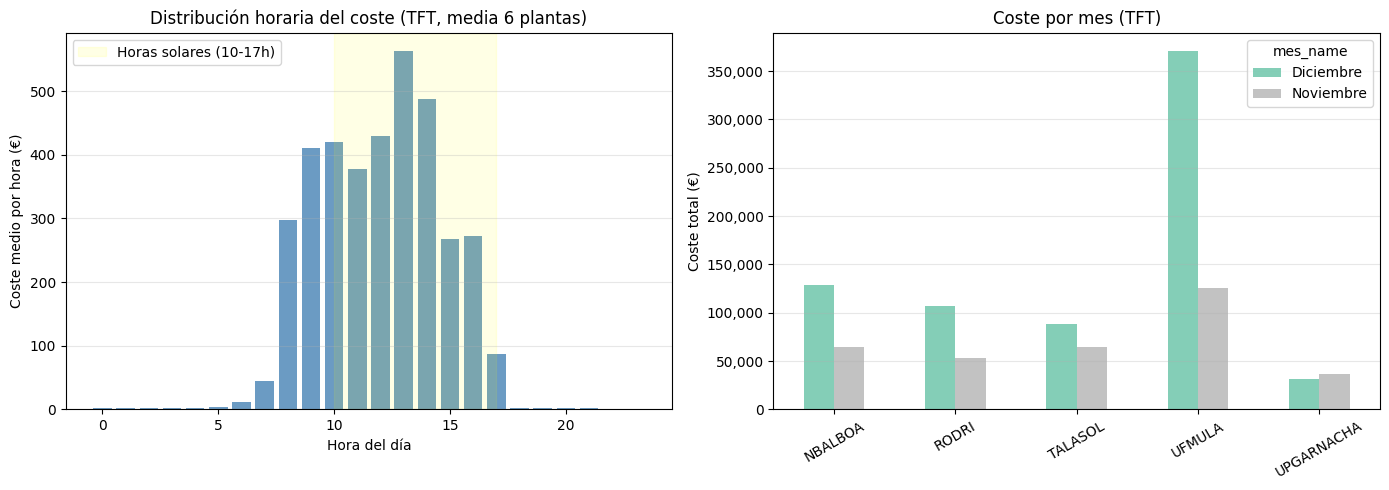

In [13]:
# ---------------------------------------------------------------------------
# CELDA 10 — Distribución horaria y mensual del coste (solo TFT, 6 plantas)
# ---------------------------------------------------------------------------

if 'TFT' in preds_ex1:
    hourly_rows = []

    for planta in PLANTAS:
        df_p = preds_ex1['TFT']
        df_p = df_p[df_p['planta_nombre'] == planta]
        if len(df_p) == 0:
            continue

        cost_df = calculate_imbalance_cost(df_p['y_true'], df_p['y_pred'], prices)
        cost_df['hora_dia'] = cost_df.index.hour
        cost_df['mes']      = cost_df.index.month
        cost_df['planta']   = planta
        hourly_rows.append(cost_df)

    if hourly_rows:
        df_hourly = pd.concat(hourly_rows)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Distribución por hora del día
        cost_by_hour = df_hourly.groupby('hora_dia')['coste_total_eur'].mean()
        axes[0].bar(cost_by_hour.index, cost_by_hour.values, color='steelblue', alpha=0.8)
        axes[0].set_xlabel('Hora del día')
        axes[0].set_ylabel('Coste medio por hora (€)')
        axes[0].set_title('Distribución horaria del coste (TFT, media 6 plantas)')
        axes[0].axvspan(10, 17, alpha=0.1, color='yellow', label='Horas solares (10-17h)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3, axis='y')

        # Por mes (Nov vs Dic)
        cost_by_month = df_hourly.groupby(['mes', 'planta'])['coste_total_eur'].sum().reset_index()
        mes_names = {11: 'Noviembre', 12: 'Diciembre'}
        cost_by_month['mes_name'] = cost_by_month['mes'].map(mes_names)

        pivot_mes = cost_by_month.pivot_table(values='coste_total_eur', index='planta', columns='mes_name')
        pivot_mes.plot(kind='bar', ax=axes[1], colormap='Set2', alpha=0.8)
        axes[1].set_xlabel('')
        axes[1].set_ylabel('Coste total (€)')
        axes[1].set_title('Coste por mes (TFT)')
        axes[1].tick_params(axis='x', rotation=30)
        axes[1].grid(True, alpha=0.3, axis='y')
        axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

        plt.tight_layout()
        plt.savefig(FIG_DIR / 'economic_temporal_dist.png', dpi=150, bbox_inches='tight')
        plt.show()

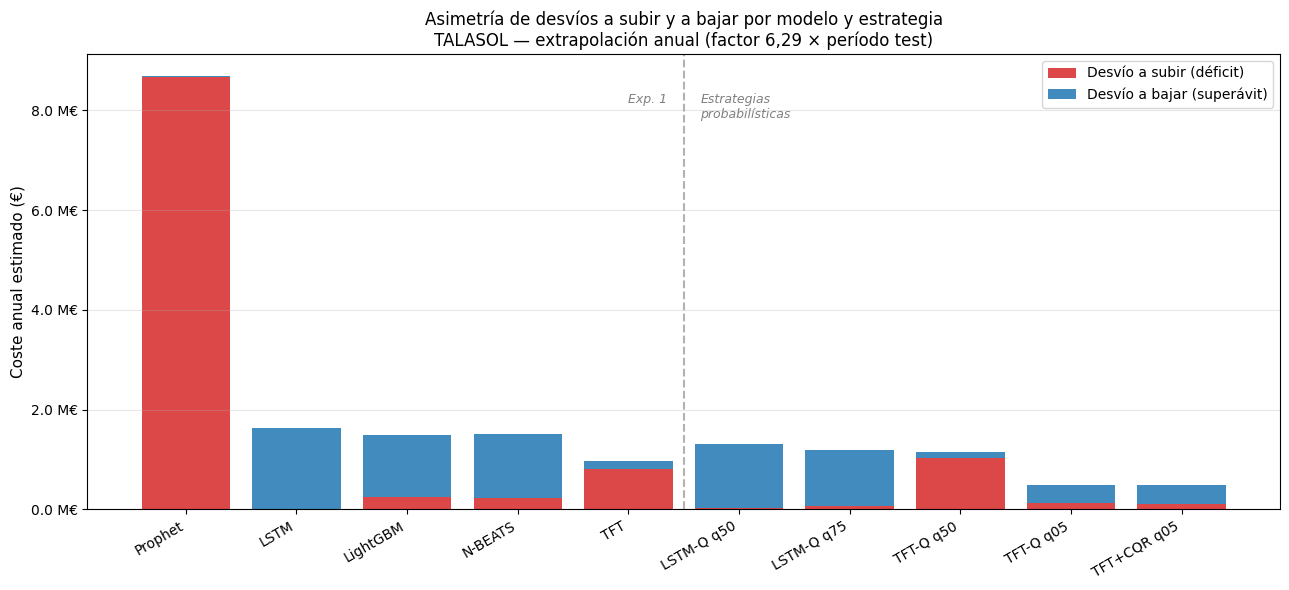

Guardado: economic_asymmetry_by_model.png


In [14]:
# ---------------------------------------------------------------------------
# CELDA 10b — Fig. 5.5.5: Asimetría de desvíos a subir/bajar por modelo y estrategia
#             Barras apiladas anualizadas — TALASOL
# ---------------------------------------------------------------------------

# ── 1. Datos Exp. 1 desde df_costs_ex1 (TALASOL, valores test→anual × ANNUAL_FACTOR)
modelos_exp1_orden = ['Prophet', 'LSTM', 'LightGBM', 'N-BEATS', 'TFT']

df_tal = (
    df_costs_ex1[df_costs_ex1['planta'] == 'TALASOL']
    .set_index('modelo')
)

rows_exp1 = []
for m in modelos_exp1_orden:
    if m in df_tal.index:
        rows_exp1.append({
            'label': m,
            'subir': round(df_tal.loc[m, 'desvio_subir_eur'] * ANNUAL_FACTOR),
            'bajar': round(df_tal.loc[m, 'desvio_bajar_eur'] * ANNUAL_FACTOR),
        })

# ── 2. Estrategias probabilísticas — valores anuales de Tabla 5.5.5
rows_prob = [
    {'label': 'LSTM-Q q50',  'subir':    34_284, 'bajar': 1_269_637},
    {'label': 'LSTM-Q q75',  'subir':    67_957, 'bajar': 1_126_047},
    {'label': 'TFT-Q q50',   'subir': 1_028_096, 'bajar':   126_658},
    {'label': 'TFT-Q q05',   'subir':   120_932, 'bajar':   377_069},
    {'label': 'TFT+CQR q05', 'subir':   117_568, 'bajar':   378_547},
]

all_rows = rows_exp1 + rows_prob
labels   = [r['label'] for r in all_rows]
subir_v  = [r['subir']  for r in all_rows]
bajar_v  = [r['bajar']  for r in all_rows]
n_exp1   = len(rows_exp1)

# ── 3. Figura
fig, ax = plt.subplots(figsize=(13, 6))
x = list(range(len(labels)))

ax.bar(x, subir_v, label='Desvío a subir (déficit)',   color='#d62728', alpha=0.85)
ax.bar(x, bajar_v, label='Desvío a bajar (superávit)', color='#1f77b4', alpha=0.85,
       bottom=subir_v)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Coste anual estimado (€)', fontsize=11)
ax.set_title(
    'Asimetría de desvíos a subir y a bajar por modelo y estrategia\n'
    'TALASOL — extrapolación anual (factor 6,29 × período test)',
    fontsize=12
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f} M€'))
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# Separador visual entre Exp. 1 y estrategias probabilísticas
ax.axvline(n_exp1 - 0.5, color='gray', linewidth=1.5, linestyle='--', alpha=0.6)
y_top = max(s + b for s, b in zip(subir_v, bajar_v))
ax.text(n_exp1 - 0.5 - 0.15, y_top * 0.96, 'Exp. 1',
        ha='right', va='top', fontsize=9, color='gray', style='italic')
ax.text(n_exp1 - 0.5 + 0.15, y_top * 0.96, 'Estrategias\nprobabilísticas',
        ha='left',  va='top', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig(FIG_DIR / 'economic_asymmetry_by_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: economic_asymmetry_by_model.png')


In [15]:
# ---------------------------------------------------------------------------
# CELDA 11 — Análisis de sensibilidad de precios (percentiles 10/50/90)
# ---------------------------------------------------------------------------

if 'TFT' in preds_ex1 and 'TALASOL' in preds_ex1['TFT']['planta_nombre'].values:
    df_talasol = preds_ex1['TFT'][preds_ex1['TFT']['planta_nombre'] == 'TALASOL']

    scenarios_price = {}
    for pct in [10, 25, 50, 75, 90]:
        p_scenario = prices.copy()
        p_scenario['cobro_subir_eur_mwh'] = np.percentile(
            prices['cobro_subir_eur_mwh'].dropna(), pct
        )
        p_scenario['pago_bajar_eur_mwh'] = np.percentile(
            prices['pago_bajar_eur_mwh'].dropna(), pct
        )
        p_scenario['spot_eur_mwh'] = np.percentile(
            prices['spot_eur_mwh'].dropna(), pct
        )
        cost_s = calculate_imbalance_cost(df_talasol['y_true'], df_talasol['y_pred'], p_scenario)
        scenarios_price[f'p{pct}'] = cost_s['coste_total_eur'].sum() * ANNUAL_FACTOR

    print('=== Sensibilidad del coste anual (TALASOL, TFT) a los precios ===')
    for escenario, coste in scenarios_price.items():
        print(f'  {escenario}: {coste:,.0f} €/año')

    # Sensibilidad por modelo (usando precios reales)
    print()
    print('=== Ahorro anual de TFT respecto a cada modelo (TALASOL) ===')
    if 'df_costs_ex1' in dir():
        costes_talasol = df_costs_ex1[df_costs_ex1['planta'] == 'TALASOL'].set_index('modelo')['coste_anual_eur']
        if 'TFT' in costes_talasol.index:
            for m, c in costes_talasol.items():
                ahorro = c - costes_talasol['TFT']
                print(f'  {m} vs TFT: {ahorro:+,.0f} €/año')

=== Sensibilidad del coste anual (TALASOL, TFT) a los precios ===
  p10: -158,519 €/año
  p25: 93,454 €/año
  p50: 1,091,623 €/año
  p75: 1,852,880 €/año
  p90: 2,367,701 €/año

=== Ahorro anual de TFT respecto a cada modelo (TALASOL) ===
  Prophet vs TFT: +7,726,380 €/año
  LightGBM vs TFT: +531,638 €/año
  LSTM vs TFT: +675,966 €/año
  N-BEATS vs TFT: +555,480 €/año
  TFT vs TFT: +0 €/año


---
## Bloque 5: Valor económico del Transfer Learning (TALASOL, Exp 2)

> **Dependencia:** Los notebooks de Exp 2 deben guardar predicciones horarias en CSV.
> Se espera el fichero `results/ex2_transfer/{model}/predictions_TALASOL.csv`  
> con columnas `[timestamp, y_true, y_pred, scenario]`.
> Si no existe, este bloque se omite con un aviso.

    modelo            scenario  coste_test_eur  coste_anual_eur
0     LSTM           zero_shot       213580.19        1345048.0
1     LSTM         ft_1_semana       213908.84        1347118.0
2     LSTM            ft_1_mes       270367.68        1702675.0
3     LSTM          ft_3_meses       223228.44        1405810.0
4     LSTM  ft_frozen_1_semana       220706.35        1389926.0
5     LSTM     ft_frozen_1_mes       219353.37        1381406.0
6     LSTM   ft_frozen_3_meses       234565.68        1477207.0
7     LSTM            baseline       240428.07        1514126.0
8   NBEATS           zero_shot       236911.91        1491983.0
9   NBEATS         ft_1_semana       226379.03        1425651.0
10  NBEATS            ft_1_mes       220495.83        1388601.0
11  NBEATS          ft_3_meses       220453.03        1388331.0
12  NBEATS  ft_frozen_1_semana       234567.07        1477216.0
13  NBEATS     ft_frozen_1_mes       234592.24        1477375.0
14  NBEATS   ft_frozen_3_meses       234

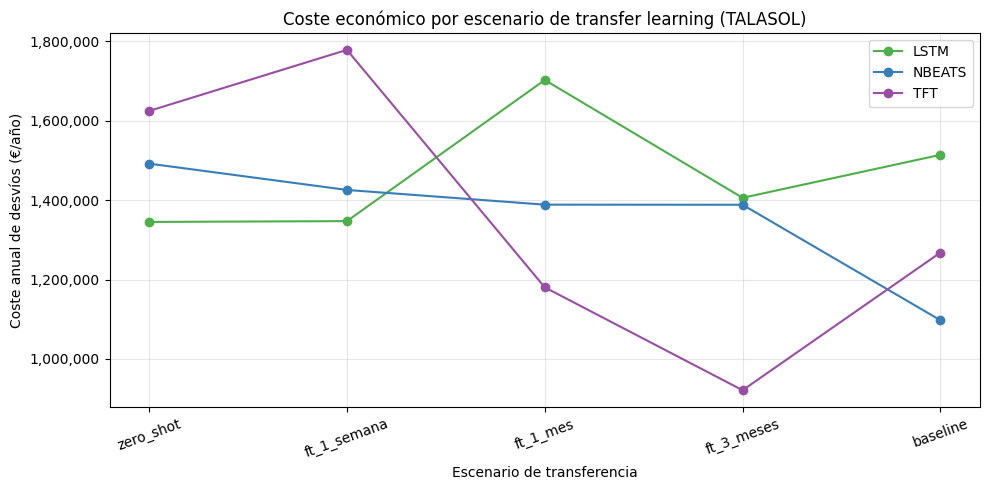

In [16]:
# ---------------------------------------------------------------------------
# CELDA 12 — Coste económico por escenario de transferencia (TALASOL)
# ---------------------------------------------------------------------------

MODELOS_EX2 = ['lstm', 'nbeats', 'tft']
records_ex2 = []
ex2_available = False

def _parse_timestamps(series):
    """Parsea timestamps con o sin timezone y devuelve datetime64 naive (UTC)."""
    ts = pd.to_datetime(series, format='ISO8601', utc=True)
    return ts.dt.tz_localize(None).dt.floor('h')

for model_key in MODELOS_EX2:
    pred_path = EX2_DIR / model_key / 'predictions_TALASOL.csv'
    if not pred_path.exists():
        print(f'  AVISO: {pred_path} no encontrado. Añadir guardado de predicciones en ex2 notebooks.')
        continue

    ex2_available = True
    df_ex2 = pd.read_csv(pred_path)
    df_ex2['timestamp'] = _parse_timestamps(df_ex2['timestamp'])
    df_ex2 = df_ex2.set_index('timestamp')

    # Excluir filas con valid_data=False (curtailment o huecos largos)
    if 'valid_data' in df_ex2.columns:
        n_antes = len(df_ex2)
        df_ex2 = df_ex2[df_ex2['valid_data'].fillna(True).astype(bool)]
        n_filtradas = n_antes - len(df_ex2)
        if n_filtradas > 0:
            print(f'  {model_key}: {n_filtradas} filas excluidas por valid_data=False')

    for scenario in df_ex2['scenario'].unique():
        df_s = df_ex2[df_ex2['scenario'] == scenario]
        cost_df = calculate_imbalance_cost(df_s['y_true'], df_s['y_pred'], prices)

        records_ex2.append({
            'modelo':          model_key.upper(),
            'scenario':        scenario,
            'coste_test_eur':  round(cost_df['coste_total_eur'].sum(), 2),
            'coste_anual_eur': round(cost_df['coste_total_eur'].sum() * ANNUAL_FACTOR, 0),
        })

if not ex2_available:
    print('Bloque 5 omitido: sin datos de predicciones Exp 2.')
    print('Para activarlo, añadir guardado de predictions_TALASOL.csv en los notebooks ex2.')
else:
    df_costs_ex2 = pd.DataFrame(records_ex2)
    df_costs_ex2.to_csv(OUT_DIR / 'economic_valuation_ex2_transfer.csv', index=False)
    print(df_costs_ex2.to_string())

    # Ordenar escenarios para visualización
    SCENARIO_ORDER = ['zero_shot', 'ft_1_semana', 'ft_1_mes', 'ft_3_meses', 'baseline']

    fig, ax = plt.subplots(figsize=(10, 5))
    colors_ex2 = {'LSTM': '#4daf4a', 'NBEATS': '#377eb8', 'TFT': '#984ea3'}

    for modelo in ['LSTM', 'NBEATS', 'TFT']:
        sub = df_costs_ex2[df_costs_ex2['modelo'] == modelo]
        sub = sub[sub['scenario'].isin(SCENARIO_ORDER)]
        sub['order'] = sub['scenario'].map({s: i for i, s in enumerate(SCENARIO_ORDER)})
        sub = sub.sort_values('order')
        ax.plot(sub['scenario'], sub['coste_anual_eur'],
                marker='o', label=modelo, color=colors_ex2.get(modelo, 'gray'))

    ax.set_xlabel('Escenario de transferencia')
    ax.set_ylabel('Coste anual de desvíos (€/año)')
    ax.set_title('Coste económico por escenario de transfer learning (TALASOL)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'economic_transfer_curve.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## Bloque 6: Valor de la predicción probabilística (TALASOL, Exp 3)

> **Dependencia:** Los notebooks de Exp 3 deben guardar predicciones cuantílicas en CSV.  
> Se espera `results/ex3_probabilistic/{model}/predictions_TALASOL.csv`  
> con columnas `[timestamp, y_true, q_10, q_25, q_50, q_75, q_90]`.

     modelo variante          estrategia  coste_anual_eur
0      LSTM      raw  q_05 (conservador)        1677080.0
1      LSTM      raw                q_25        1429864.0
2      LSTM      raw      q_50 (mediana)        1311451.0
3      LSTM      raw                q_75        1199560.0
4      LSTM      raw    q_95 (optimista)        1556763.0
5       TFT      raw  q_05 (conservador)         504208.0
6       TFT      raw                q_25         676420.0
7       TFT      raw      q_50 (mediana)        1184764.0
8       TFT      raw                q_75        2176737.0
9       TFT      raw    q_95 (optimista)        4245375.0
10  TFT+CQR      cqr  q_05 (conservador)         501804.0
11  TFT+CQR      cqr                q_25         676420.0
12  TFT+CQR      cqr      q_50 (mediana)        1184764.0
13  TFT+CQR      cqr                q_75        2176737.0
14  TFT+CQR      cqr    q_95 (optimista)        4290593.0


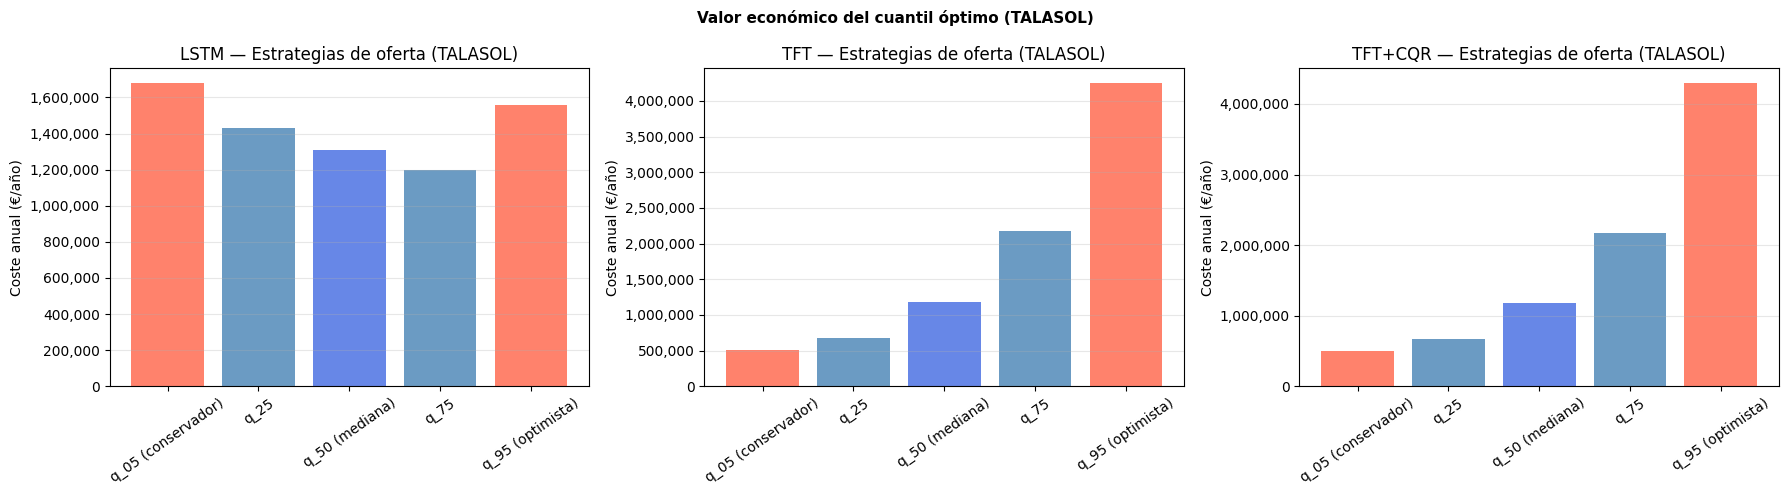

In [17]:
# ---------------------------------------------------------------------------
# CELDA 13 — Valor económico de ofrecer cuantil óptimo vs. media (TALASOL)
# ---------------------------------------------------------------------------
#
# Columnas esperadas en predictions_TALASOL.csv:
#   [timestamp, y_true, q_05, q_25, q_50, q_75, q_95]
# (QUANTILES = [0.05, 0.25, 0.50, 0.75, 0.95])
#
# Para TFT se carga también predictions_TALASOL_CQR.csv (intervalos calibrados)

records_ex3 = []
ex3_available = False

# Estrategias de oferta → columnas en el CSV de predicciones
estrategias = {
    'q_05 (conservador)': 'q_05',
    'q_25':               'q_25',
    'q_50 (mediana)':     'q_50',
    'q_75':               'q_75',
    'q_95 (optimista)':   'q_95',
}

def _load_ex3_preds(filepath):
    """Carga CSV de predicciones ex3; filtra valid_data=False si existe."""
    df = pd.read_csv(filepath)
    ts = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True)
    df['timestamp'] = ts.dt.tz_localize(None).dt.floor('h')
    df = df.set_index('timestamp')
    if 'valid_data' in df.columns:
        n_antes = len(df)
        df = df[df['valid_data'].fillna(True).astype(bool)]
        n_filtradas = n_antes - len(df)
        if n_filtradas > 0:
            print(f'  {filepath.name}: {n_filtradas} filas excluidas por valid_data=False')
    return df

for model_key in ['lstm', 'tft']:
    pred_path = EX3_DIR / model_key / 'predictions_TALASOL.csv'
    if not pred_path.exists():
        print(f'  AVISO: {pred_path} no encontrado. Ejecutar ex3 notebooks primero.')
        continue

    ex3_available = True
    df_ex3 = _load_ex3_preds(pred_path)
    y_real = df_ex3['y_true']

    label_prefix = model_key.upper()

    for label, col in estrategias.items():
        if col not in df_ex3.columns:
            print(f'  AVISO: columna {col} no encontrada en {pred_path}')
            continue
        cost_df = calculate_imbalance_cost(y_real, df_ex3[col], prices)
        records_ex3.append({
            'modelo':          label_prefix,
            'variante':        'raw',
            'estrategia':      label,
            'coste_test_eur':  round(cost_df['coste_total_eur'].sum(), 2),
            'coste_anual_eur': round(cost_df['coste_total_eur'].sum() * ANNUAL_FACTOR, 0),
        })

    # Para TFT: también cargar versión CQR calibrada
    if model_key == 'tft':
        cqr_path = EX3_DIR / 'tft' / 'predictions_TALASOL_CQR.csv'
        if cqr_path.exists():
            df_cqr = _load_ex3_preds(cqr_path)
            y_real_cqr = df_cqr['y_true']

            for label, col in estrategias.items():
                if col not in df_cqr.columns:
                    continue
                cost_df = calculate_imbalance_cost(y_real_cqr, df_cqr[col], prices)
                records_ex3.append({
                    'modelo':          'TFT+CQR',
                    'variante':        'cqr',
                    'estrategia':      label,
                    'coste_test_eur':  round(cost_df['coste_total_eur'].sum(), 2),
                    'coste_anual_eur': round(cost_df['coste_total_eur'].sum() * ANNUAL_FACTOR, 0),
                })

if not ex3_available:
    print('Bloque 6 omitido: sin datos de predicciones cuantílicas Exp 3.')
    print('Para activarlo, ejecutar los notebooks ex3 (01_lstm_quantile, 02_tft_quantile).')
else:
    df_costs_ex3 = pd.DataFrame(records_ex3)
    df_costs_ex3.to_csv(OUT_DIR / 'economic_valuation_ex3_probabilistic.csv', index=False)
    print(df_costs_ex3[['modelo', 'variante', 'estrategia', 'coste_anual_eur']].to_string())

    # --- Visualización: coste por estrategia para cada modelo/variante ---
    modelos_plot = df_costs_ex3['modelo'].unique()
    n_modelos = len(modelos_plot)
    fig, axes = plt.subplots(1, n_modelos, figsize=(6 * n_modelos, 5), sharey=False)
    if n_modelos == 1:
        axes = [axes]

    for ax, modelo in zip(axes, modelos_plot):
        sub = df_costs_ex3[df_costs_ex3['modelo'] == modelo]
        color_map = {
            'q_05 (conservador)': 'tomato',
            'q_25':               'steelblue',
            'q_50 (mediana)':     'royalblue',
            'q_75':               'steelblue',
            'q_95 (optimista)':   'tomato',
        }
        bars = ax.bar(sub['estrategia'], sub['coste_anual_eur'],
                      color=[color_map.get(e, 'steelblue') for e in sub['estrategia']],
                      alpha=0.8)
        ax.set_title(f'{modelo} — Estrategias de oferta (TALASOL)')
        ax.set_ylabel('Coste anual (€/año)')
        ax.tick_params(axis='x', rotation=35)
        ax.grid(True, alpha=0.3, axis='y')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    plt.suptitle('Valor económico del cuantil óptimo (TALASOL)', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'economic_probabilistic_strategies.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## Bloque 7: Resumen consolidado

In [18]:
# ---------------------------------------------------------------------------
# CELDA 14 — Tabla resumen final + exportación
# ---------------------------------------------------------------------------

print('=' * 65)
print('  RESUMEN — EXPERIMENTO 5: VALORACIÓN ECONÓMICA')
print('=' * 65)

if 'df_costs_ex1' in dir() and len(df_costs_ex1) > 0:
    print()
    print('--- Exp 1: Coste anual medio por modelo (media 6 plantas) ---')
    mean_by_model = df_costs_ex1.groupby('modelo')['coste_anual_eur'].mean().sort_values()
    for m, c in mean_by_model.items():
        print(f'  {m:<12}: {c:>10,.0f} €/año')

    print()
    print('--- Ahorro anual vs. Prophet (modelo más simple) ---')
    if 'Prophet' in mean_by_model.index:
        for m, c in mean_by_model.items():
            if m != 'Prophet':
                ahorro = mean_by_model['Prophet'] - c
                pct = ahorro / mean_by_model['Prophet'] * 100
                print(f'  {m:<12}: {ahorro:>+10,.0f} €/año  ({pct:+.1f}%)')

    print()
    print('--- TALASOL — Coste por modelo (€/año) ---')
    talasol_costs = df_costs_ex1[df_costs_ex1['planta'] == 'TALASOL'][['modelo', 'coste_anual_eur']]
    for _, row in talasol_costs.sort_values('coste_anual_eur').iterrows():
        print(f'  {row["modelo"]:<12}: {row["coste_anual_eur"]:>10,.0f} €/año')

if ex2_available and 'df_costs_ex2' in dir():
    print()
    print('--- Exp 2: Coste por escenario de transferencia (TALASOL, TFT) ---')
    sub = df_costs_ex2[df_costs_ex2['modelo'] == 'TFT']
    for _, row in sub.iterrows():
        print(f'  {row["scenario"]:<20}: {row["coste_anual_eur"]:>10,.0f} €/año')

if ex3_available and 'df_costs_ex3' in dir():
    print()
    print('--- Exp 3: Valor del cuantil óptimo (TALASOL, TFT) ---')
    sub = df_costs_ex3[df_costs_ex3['modelo'] == 'TFT']
    for _, row in sub.iterrows():
        print(f'  {row["estrategia"]:<30}: {row["coste_anual_eur"]:>10,.0f} €/año')

print()
print('--- Archivos generados ---')
for f in OUT_DIR.glob('economic_*.csv'):
    print(f'  {f}')
for f in FIG_DIR.glob('economic_*.png'):
    print(f'  {f}')

print()
print('Experimento 5 completado.')

  RESUMEN — EXPERIMENTO 5: VALORACIÓN ECONÓMICA

--- Exp 1: Coste anual medio por modelo (media 6 plantas) ---
  TFT         :  1,347,759 €/año
  LightGBM    :  1,394,822 €/año
  LSTM        :  1,460,823 €/año
  N-BEATS     :  2,176,690 €/año
  Prophet     :  5,134,769 €/año

--- Ahorro anual vs. Prophet (modelo más simple) ---
  TFT         : +3,787,010 €/año  (+73.8%)
  LightGBM    : +3,739,947 €/año  (+72.8%)
  LSTM        : +3,673,947 €/año  (+71.6%)
  N-BEATS     : +2,958,079 €/año  (+57.6%)

--- TALASOL — Coste por modelo (€/año) ---
  TFT         :    966,099 €/año
  LightGBM    :  1,497,737 €/año
  N-BEATS     :  1,521,579 €/año
  LSTM        :  1,642,065 €/año
  Prophet     :  8,692,479 €/año

--- Exp 2: Coste por escenario de transferencia (TALASOL, TFT) ---
  zero_shot           :  1,624,664 €/año
  ft_1_semana         :  1,778,615 €/año
  ft_1_mes            :  1,180,275 €/año
  ft_3_meses          :    921,063 €/año
  ft_frozen_1_semana  :  2,195,448 €/año
  ft_frozen_1_me